# Análisis de experimentos WebGazer con pyxations

Este notebook reemplaza el pipeline custom del repo por las herramientas de **pyxations**.

Cubre ambos experimentos:
- `precision_experiment/`
- `antisaccade_experiment/`

Lo que pyxations hace por nosotros:
- Parsea los CSV de WebGazer (JSON embebido → DataFrame de muestras)
- Corre REMoDNaV (detección fijaciones/sacadas) como API Python, sin `os.system()`
- Guarda todo en formato BIDS + feather (un archivo por sujeto, no 1000+ TSVs)
- Segmentación de trials con `PreProcessing`

Lo que sigue siendo código custom:
- Lógica cognitiva antisacada (clasificación errores, reaction times)
- Normalización de coordenadas relativa a baseline
- Métricas de precisión específicas del experimento

## 0. Setup

In [1]:
# IMPORTANTE: usar python3.10 (no el python3 del sistema que es 3.8)
# En terminal: python3.10 -m jupyter notebook

from pathlib import Path
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.feather as feather

from pyxations.bids_formatting import dataset_to_bids, compute_derivatives_for_dataset

print("pyxations OK")

REPO_ROOT = Path(".").resolve()
print(f"Working dir: {REPO_ROOT}")

pyxations OK
Working dir: /home/gus/Documents/REPOS/et_webcam_experiments


---
## 1. Experimento antisacada

### 1.1 Preparar archivos para pyxations

pyxations espera que los archivos se llamen `{subject_id}_{...}.csv`  
(sujeto primero, luego descripción).  
Los archivos originales son `antisacadas_{subject_id}.csv`, hay que reordenarlos.  
Hacemos copias en un directorio temporal — **no tocamos los originales**.

In [2]:
RAW_ANTI = REPO_ROOT / "antisaccade_experiment" / "raw_data"
ANTI_STAGING = REPO_ROOT / "antisaccade_experiment" / "_staging"  # temporal
ANTI_STAGING.mkdir(exist_ok=True)

for csv_file in RAW_ANTI.glob("antisacadas_*.csv"):
    subject_id = csv_file.stem.split("_")[1]          # "100", "101", ...
    new_name = f"{subject_id}_antisacadas.csv"         # "100_antisacadas.csv"
    dest = ANTI_STAGING / new_name
    if not dest.exists():
        shutil.copy(csv_file, dest)

print(f"Archivos preparados: {len(list(ANTI_STAGING.glob('*.csv')))} sujetos")
print([f.name for f in sorted(ANTI_STAGING.glob('*.csv'))][:5], "...")

Archivos preparados: 26 sujetos
['100_antisacadas.csv', '101_antisacadas.csv', '102_antisacadas.csv', '103_antisacadas.csv', '104_antisacadas.csv'] ...


### 1.2 Convertir a BIDS

In [3]:
ANTI_BIDS = REPO_ROOT / "antisaccade_experiment" / "bids"

bids_path = dataset_to_bids(
    target_folder_path=ANTI_BIDS,
    files_folder_path=ANTI_STAGING,
    dataset_name="antisaccade",
    session_substrings=1,
    format_name="webgazer",
)

print(f"BIDS creado en: {bids_path}")

# Verificar estructura
participants = pd.read_csv(bids_path / "participants.tsv", sep="\t")
print(f"\nParticipantes ({len(participants)}):")
print(participants.head())

BIDS creado en: /home/gus/Documents/REPOS/et_webcam_experiments/antisaccade_experiment/bids/antisaccade

Participantes (26):
   subject_id  old_subject_id
0           1              91
1           2              92
2           3              98
3           4              99
4           5             100


### 1.3 Calcular derivatives (detección de fijaciones y sacadas)

Reemplaza el loop de `os.system("remodnav ...")` que generaba ~1000 TSVs.  
pyxations corre REMoDNaV en paralelo sobre todos los sujetos y guarda en feather.

In [4]:
compute_derivatives_for_dataset(
    bids_dataset_folder=bids_path,
    dataset_format="webgazer",
    detection_algorithm="remodnav",
    num_processes=4,
    overwrite=False,  # True para recomputar
)

derivatives_path = Path(str(bids_path) + "_derivatives")
print(f"\nDerivatives guardados en: {derivatives_path}")


Derivatives guardados en: /home/gus/Documents/REPOS/et_webcam_experiments/antisaccade_experiment/bids/antisaccade_derivatives


### 1.4 Cargar muestras de un sujeto

pyxations guarda las muestras parseadas en `samples.feather` (columnas: `trial_index`, `X`, `Y`, `tSample`).  
Usamos eso en lugar de parsear el JSON a mano.

In [5]:
def load_subject_samples(derivatives_path, subject_id):
    """
    Carga las muestras de gaze de un sujeto desde los derivatives de pyxations.

    Estructura:
        sub-XXXX/ses-YYY/samples.feather
            columnas: trial_index, X, Y, tSample, t_acum, ...
    """
    sub_path = derivatives_path / f"sub-{subject_id}"
    sessions = [s for s in sub_path.iterdir() if s.name.startswith("ses-")]
    if not sessions:
        raise FileNotFoundError(f"No sessions found for sub-{subject_id}")
    ses_path = sessions[0]
    return feather.read_feather(ses_path / "samples.feather").reset_index(drop=True)


# Ejemplo: sujeto 0001
samples = load_subject_samples(derivatives_path, "0001")
print(f"Muestras: {len(samples)} filas")
print(f"Columnas: {list(samples.columns)}")
print(f"trial_index únicos: {samples['trial_index'].nunique()}")
print(samples.head(3))

Muestras: 25679 filas
Columnas: ['line_number', 'trial_index', 'time_elapsed', 'X', 'Y', 'tSample', 't_acum']
trial_index únicos: 400
   line_number  trial_index  time_elapsed     X    Y  tSample  t_acum
0           29           29        156458  1059  510        0  156458
1           29           29        156458  1078  480       73  156531
2           29           29        156458  1119  471      142  156600


### 1.5 Reconectar con los datos del experimento (CSV original)

Los metadatos de cada trial (tipo de sacada, dirección del cue, tiempos de eventos)  
siguen viniendo del CSV original — pyxations no los toca.

In [6]:
def load_trial_metadata(raw_data_path, old_subject_id):
    """
    Carga los metadatos de trials del CSV original.
    Filtra solo las filas del experimento antisacada (no tutoriales, no calibración).
    """
    csv_path = raw_data_path / f"antisacadas_{old_subject_id}.csv"
    df = pd.read_csv(csv_path)

    # Filas de la tarea (no tutoriales, no calibración)
    mask = (
        df["isSaccadeExperiment"].notna() &
        (df["isTutorial"] == False)
    )
    trials = df[mask].reset_index(drop=True).copy()

    # Extraer px2deg del CSV (primera fila que lo tenga)
    px2deg_series = df["px2deg"].dropna()
    px2deg = float(px2deg_series.iloc[0]) if not px2deg_series.empty else None

    return trials, px2deg


# Mapeo subject_id → old_subject_id desde participants.tsv
participants = pd.read_csv(bids_path / "participants.tsv", sep="\t", dtype=str)
id_map = dict(zip(participants["subject_id"], participants["old_subject_id"]))

# Ejemplo: sujeto 0001
old_id = id_map["0001"]
trials, px2deg = load_trial_metadata(RAW_ANTI, old_id)

print(f"Sujeto {old_id}: {len(trials)} trials")
print(f"px2deg: {px2deg}")
print(f"Tipos de sacada: {trials['typeOfSaccade'].value_counts().to_dict()}")

Sujeto 91: 320 trials
px2deg: 32.260000305442254
Tipos de sacada: {'prosaccade': 160, 'antisaccade': 160}


### 1.6 Análisis antisacada — misma lógica que el notebook original

Reemplazamos el parseo del JSON por la carga del `samples.feather` de pyxations.  
Todo lo demás (normalización, filtro de banda, detección de errores por threshold crossing)  
es idéntico al pipeline original.

In [7]:
def analyze_antisaccade_subject(
    trials,
    df_samples,
    sacc_type,
    baseline_start=-200.0,
    baseline_end=100.0,
    FILTER=1.5,
    threshold=0.5,
    savgol_flag=False,
):
    """
    Análisis antisacada usando las muestras parseadas por pyxations.

    Lógica idéntica al notebook original:
      1. Para cada trial, filtra muestras por trial_index
      2. Alinea tiempos a intraEnd (t=0 = onset del estímulo)
      3. Normaliza coordenadas x respecto a baseline y referencia
      4. Espeja si el cue estaba a la izquierda
      5. Filtra trials fuera de banda (|x| > FILTER)
      6. Detecta errores por primer cruce de threshold
      7. Registra RT del cruce

    Diferencia con el original: usa df_samples de pyxations en lugar de parsear JSON.
    """
    from scipy.signal import savgol_filter

    sub_trials = trials[trials["typeOfSaccade"] == sacc_type]

    errors = 0
    rt_errors = []
    rt_correct = []
    n_rejected = 0
    ts_xs_ys = []

    for _, trial in sub_trials.iterrows():
        trial_idx = trial["trial_index"]
        intra_end = trial["intraEnd"]
        cue_left  = bool(trial["cueShownAtLeft"])

        # Muestras del trial (pyxations las organiza por trial_index)
        t_samps = df_samples[df_samples["trial_index"] == trial_idx]
        if t_samps.empty:
            n_rejected += 1
            continue

        xs = t_samps["X"].to_numpy(dtype=float)
        ys = t_samps["Y"].to_numpy(dtype=float)
        ts = t_samps["tSample"].to_numpy(dtype=float) - intra_end  # t=0 en intraEnd

        # Normalización respecto a baseline [-200, 100] ms y referencia [500, 700] ms
        mask_base = (ts > baseline_start) & (ts < baseline_end)
        mask_ref  = (ts > 500) & (ts <= 700)
        if not mask_base.any() or not mask_ref.any():
            n_rejected += 1
            continue

        x_base = np.median(xs[mask_base])
        y_base = np.median(ys[mask_base])
        x_ref  = np.median(xs[mask_ref])
        y_ref  = np.median(ys[mask_ref])

        denom_x = np.abs(x_base - x_ref)
        denom_y = np.abs(y_base - y_ref)
        if denom_x == 0 or denom_y == 0:
            n_rejected += 1
            continue

        xs = (xs - x_base) / denom_x
        ys = (ys - y_base) / denom_y

        # Espejado si el cue estaba a la izquierda
        if cue_left:
            xs = xs * -1

        # Filtro de banda
        if np.any(xs > FILTER) or np.any(xs < -FILTER):
            n_rejected += 1
            continue

        # Savitzky-Golay opcional
        if savgol_flag:
            xs = savgol_filter(xs, 5, 2)

        # Detección de error por threshold crossing (igual que el original)
        xs_after = xs[ts > baseline_end]
        ts_after = ts[ts > baseline_end]

        if sacc_type == "prosaccade":
            if np.any(xs_after < -threshold):
                errors += 1
                idx = np.where(xs_after < -threshold)[0][0]
                rt_errors.append(ts_after[idx])
            else:
                idxs = np.where(xs_after >= threshold)[0]
                if len(idxs):
                    rt_correct.append(ts_after[idxs[0]])
        else:  # antisaccade
            if np.any(xs_after > threshold):
                errors += 1
                idx = np.where(xs_after > threshold)[0][0]
                rt_errors.append(ts_after[idx])
            else:
                idxs = np.where(xs_after <= -threshold)[0]
                if len(idxs):
                    rt_correct.append(ts_after[idxs[0]])

        ts_xs_ys.append((ts, xs, ys))

    n_valid = len(sub_trials) - n_rejected
    return {
        "n_total": len(sub_trials),
        "n_rejected": n_rejected,
        "n_valid": n_valid,
        "error_rate": errors / n_valid if n_valid else np.nan,
        "rt_error_median": float(np.median(rt_errors)) if rt_errors else np.nan,
        "rt_correct_median": float(np.median(rt_correct)) if rt_correct else np.nan,
        "ts_xs_ys": ts_xs_ys,  # señales normalizadas para plotear
    }


# Ejemplo: sujeto 0001
for stype in ["prosaccade", "antisaccade"]:
    res = analyze_antisaccade_subject(trials, samples, stype)
    print(f"{stype}: n_valid={res['n_valid']} | error_rate={res['error_rate']:.3f} "
          f"| rt_correct={res['rt_correct_median']:.0f}ms | rt_error={res['rt_error_median']:.0f}ms")

prosaccade: n_valid=149 | error_rate=0.040 | rt_correct=407ms | rt_error=317ms
antisaccade: n_valid=136 | error_rate=0.059 | rt_correct=489ms | rt_error=386ms


### 1.7 Loop sobre todos los sujetos

In [8]:
all_results = []

for subject_id, old_id in id_map.items():
    try:
        sub_samples = load_subject_samples(derivatives_path, subject_id)
        sub_trials, _ = load_trial_metadata(RAW_ANTI, old_id)

        for stype in ["prosaccade", "antisaccade"]:
            res = analyze_antisaccade_subject(sub_trials, sub_samples, stype)
            all_results.append({
                "subject": old_id,
                "type": stype,
                "n_valid": res["n_valid"],
                "n_rejected": res["n_rejected"],
                "error_rate": res["error_rate"],
                "rt_correct_median": res["rt_correct_median"],
                "rt_error_median": res["rt_error_median"],
            })

    except Exception as e:
        print(f"[{old_id}] Error: {e}")

df_all = pd.DataFrame(all_results)
print(f"Sujetos procesados: {df_all['subject'].nunique()}")
print()
print(df_all.groupby("type")[["n_valid", "error_rate", "rt_correct_median"]].mean().round(2))

Sujetos procesados: 26

             n_valid  error_rate  rt_correct_median
type                                               
antisaccade   134.92        0.06             454.69
prosaccade    136.35        0.05             418.81


### 1.8 Resumen grupal

In [11]:
df_all.groupby("type")[["n_valid", "error_rate", "rt_correct_median", "rt_error_median"]].mean().round(3)

,n_valid,error_rate,rt_correct_median,rt_error_median
type,,,,
antisaccade,134.923,0.063,454.692,386.288
prosaccade,136.346,0.051,418.808,402.283


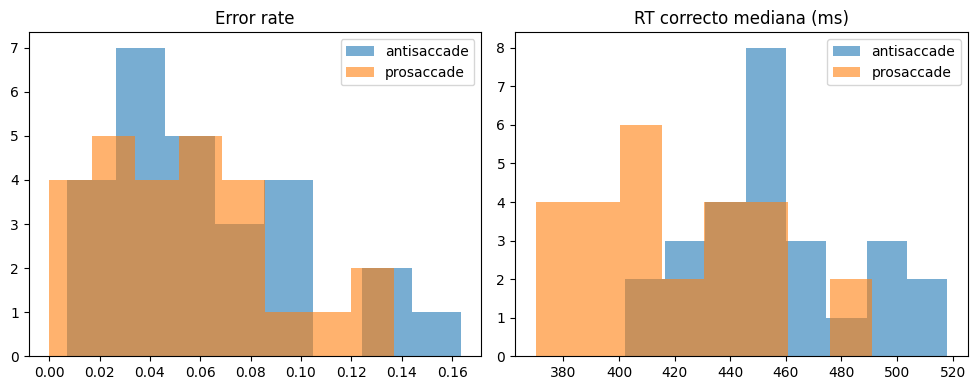

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
                                              
for ax, col, label in zip(axes,             
                         ["error_rate", "rt_correct_median"],               
                         ["Error rate", "RT correcto mediana (ms)"]):       
  for stype, grp in df_all.groupby("type"):                                 
      ax.hist(grp[col].dropna(), bins=8, alpha=0.6, label=stype)            
  ax.set_title(label)                                                       
  ax.legend()                                                               

plt.tight_layout()                                                            
plt.show()      

---
## 2. Experimento de precisión

### 2.1 Preparar archivos

In [15]:
RAW_PREC = REPO_ROOT / "precision_experiment" / "raw_data" / "precision-antisaccade-exp"
PREC_STAGING = REPO_ROOT / "precision_experiment" / "_staging"
PREC_STAGING.mkdir(exist_ok=True)

# Los archivos de precisión: listar sus nombres para ver el patrón
raw_files = sorted(RAW_PREC.glob("*.csv"))
print(f"Archivos encontrados: {len(raw_files)}")
print([f.name for f in raw_files[:5]])

Archivos encontrados: 8
['gus_webcam4.csv', 'gus_webcam8.csv', 'gus_webcam9.csv', 'juan_webcam3.csv', 'juan_webcam4.csv']


In [16]:
# Adaptar nombres al formato pyxations: {subject_id}_{resto}.csv
# Ajustar la función según el patrón real de nombres encontrado arriba
for csv_file in raw_files:
    parts = csv_file.stem.split("_")
    # Si el subject ID ya está primero: copiar tal cual
    # Si no: ajustar la lógica aquí
    dest = PREC_STAGING / csv_file.name
    if not dest.exists():
        shutil.copy(csv_file, dest)

print(f"Archivos preparados: {len(list(PREC_STAGING.glob('*.csv')))}")

Archivos preparados: 8


### 2.2 Convertir a BIDS y calcular derivatives

In [17]:
PREC_BIDS = REPO_ROOT / "precision_experiment" / "bids"

prec_bids_path = dataset_to_bids(
    target_folder_path=PREC_BIDS,
    files_folder_path=PREC_STAGING,
    dataset_name="precision",
    session_substrings=1,
    format_name="webgazer",
)

compute_derivatives_for_dataset(
    bids_dataset_folder=prec_bids_path,
    dataset_format="webgazer",
    detection_algorithm="remodnav",
    num_processes=4,
    overwrite=False,
)

prec_derivatives_path = Path(str(prec_bids_path) + "_derivatives")
print(f"Derivatives: {prec_derivatives_path}")


Running eye movements detection for None eye...

Running eye movements detection for None eye...

Running eye movements detection for None eye...

Running eye movements detection for None eye...
Dropping saccades with average vel > 1000.0 deg/s, and fixations with amplitude > 1.5 deg
Kept 4 out of 25 fixations
Kept 34 out of 34 saccades
Finding previous and next saccadesDropping saccades with average vel > 1000.0 deg/s, and fixations with amplitude > 1.5 deg

Kept 13 out of 93 fixations


  0%|                                                     | 0/4 [00:00<?, ?it/s]

Kept 100 out of 100 saccades
Finding previous and next saccades

100%|███████████████████████████████████████████| 4/4 [00:00<00:00, 1229.19it/s]


  0%|                                                    | 0/13 [00:00<?, ?it/s]

...

Skipping preprocessing: not enough parameters.
Dropping saccades with average vel > 1000.0 deg/s, and fixations with amplitude > 1.5 deg
Kept 3 out of 13 fixations
Kept 21 out of 21 saccades
Finding previous and next saccades


100%|███████████████████████████████████████████| 3/3 [00:00<00:00, 1579.97it/s]



Kept 2 fixations with previous saccade
Computing average pupil size, and x and y position


  0%|                                                     | 0/2 [00:00<?, ?it/s]/home/gus/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gus/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gus/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gus/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|████████████████████████████████████████████| 2/2 [00:00<00:00, 804.82it/s]


Skipping preprocessing: not enough parameters.
Derivatives: /home/gus/Documents/REPOS/et_webcam_experiments/precision_experiment/bids/precision_derivatives


### 2.3 Métricas de precisión usando fijaciones de pyxations

pyxations detecta fijaciones (centroide + duración).  
Usamos esas fijaciones durante los trials de validación para calcular  
el error respecto al punto presentado.

In [18]:
def compute_precision_metrics(csv_path, df_fixations, trial_tag="validation"):
    """
    Calcula error de precisión usando las fijaciones detectadas por pyxations.

    Parameters
    ----------
    csv_path : Path
        CSV original del sujeto.
    df_fixations : pd.DataFrame
        Fijaciones de pyxations (columnas: tStart, tEnd, xAvg, yAvg).
    trial_tag : str
        Valor de 'trial-tag' para filtrar trials de validación.

    Returns
    -------
    pd.DataFrame con error por punto de validación.
    """
    df = pd.read_csv(csv_path)
    validations = df[df["trial-tag"] == trial_tag].copy() if "trial-tag" in df.columns else df

    results = []
    for _, row in validations.iterrows():
        t_start = row.get("time_elapsed", None)
        if t_start is None:
            continue

        center_x = row.get("center_x", np.nan)
        center_y = row.get("center_y", np.nan)

        # Buscar fijaciones que ocurren durante este trial
        # (aproximación: usando time_elapsed como inicio)
        rt = row.get("rt", 1000)  # duración del trial
        t_end = t_start + rt

        fix_in_trial = df_fixations[
            (df_fixations["tStart"] >= t_start) &
            (df_fixations["tEnd"] <= t_end)
        ]

        if fix_in_trial.empty:
            continue

        # Centroide de las fijaciones durante el trial
        gaze_x = fix_in_trial["xAvg"].mean()
        gaze_y = fix_in_trial["yAvg"].mean()

        err_x = gaze_x - center_x
        err_y = gaze_y - center_y
        err_total = np.sqrt(err_x**2 + err_y**2)

        results.append({
            "center_x": center_x,
            "center_y": center_y,
            "gaze_x": gaze_x,
            "gaze_y": gaze_y,
            "err_x_px": err_x,
            "err_y_px": err_y,
            "err_total_px": err_total,
            "n_fixations": len(fix_in_trial),
        })

    return pd.DataFrame(results)


print("Función lista. Ejecutar por sujeto con los derivatives de precisión.")

Función lista. Ejecutar por sujeto con los derivatives de precisión.


### 2.4 Visualización con pyxations

pyxations tiene su propia clase `Visualization` para scanpaths y plots de gaze.

In [21]:
from pyxations.visualization.visualization import Visualization

# Descomentar cuando los derivatives de precisión estén generados:
sub_samples_prec = load_subject_samples(prec_derivatives_path, "0001")
viz = Visualization(sub_samples_prec, pd.DataFrame(), pd.DataFrame())
viz.scanpath()

print("Visualization importada correctamente.")


TypeError: Visualization.__init__() takes 3 positional arguments but 4 were given

---
## Notas

- Los directorios `_staging/` son temporales. Se pueden borrar después de generar los BIDS.
- Los `_derivatives/` contienen todo el output de pyxations (feather por sujeto).
- Para re-correr la detección: pasar `overwrite=True` a `compute_derivatives_for_dataset`.
- La lógica de errores antisacada en la sección 1.6 es específica de la tarea —  
  pyxations detecta los movimientos, pero la clasificación correcto/incorrecto  
  sigue siendo responsabilidad del análisis.